In [5]:
from pathlib import Path
from dataclasses import dataclass
import importlib.util
import inspect
import sys
from typing import Dict, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

CWD = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [CWD, *CWD.parents, CWD / "allhands_meeting" / "pcmdi_package"]:
    reader_path = candidate / "scripts" / "pcmdi_enso_reader.py"
    if reader_path.is_file() and (candidate / "jupyter").is_dir():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate pcmdi_package/scripts/pcmdi_enso_reader.py.")

READER_PATH = PROJECT_ROOT / "scripts" / "pcmdi_enso_reader.py"
reader_spec = importlib.util.spec_from_file_location("pcmdi_enso_reader_local", READER_PATH)
if reader_spec is None or reader_spec.loader is None:
    raise ImportError(f"Could not load ENSO reader from {READER_PATH}")
pcmdi_enso_reader_local = importlib.util.module_from_spec(reader_spec)
reader_spec.loader.exec_module(pcmdi_enso_reader_local)
ENSODiagReader = pcmdi_enso_reader_local.ENSODiagReader

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))
from metrics_group_merger import PCMDIRun

@dataclass(frozen=True)
class EnsembleSource:
    data_dir: Path
    model: str
    group: str
    period: tuple
    nens: int
    members: Optional[Sequence[int]] = None
    case_id: Optional[str] = None

reader_signature = inspect.signature(ENSODiagReader.load_metric_data)
if "case_id" not in reader_signature.parameters:
    raise RuntimeError(f"Reader at {READER_PATH} does not support case_id: {reader_signature}")
print(f"Loaded ENSODiagReader from {READER_PATH}")


Loaded ENSODiagReader from /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/pcmdi_package/scripts/pcmdi_enso_reader.py


In [6]:
class ENSOFeedbackPlotter:
    """Plot one longitude-dependent ENSO feedback metric for one or more groups."""

    def __init__(
        self,
        data_dict: Dict[str, xr.DataArray],
        fig_dir: Path,
        plot_dict: Dict[str, Dict[str, object]],
        group_order: Sequence[str],
        obs_key: str = "reference",
    ):
        if not group_order:
            raise ValueError("At least one comparison group is required")
        self.data_dict = data_dict
        self.fig_dir = Path(fig_dir)
        self.plot_dict = plot_dict
        self.group_order = tuple(group_order)
        self.obs_key = obs_key

    @staticmethod
    def _format_lon(lon: float) -> str:
        lon = float(lon) % 360
        if np.isclose(lon, 0):
            return "0°"
        if np.isclose(lon, 180):
            return "180°"
        return f"{int(lon)}°E" if lon < 180 else f"{int(360 - lon)}°W"

    @staticmethod
    def _prepare_model(da: xr.DataArray) -> xr.DataArray:
        if "sample" in da.dims and "member" not in da.dims:
            da = da.rename({"sample": "member"})
        if "member" not in da.dims:
            other = [dim for dim in da.dims if dim != "longitude"]
            if len(other) == 1:
                da = da.rename({other[0]: "member"})
            else:
                raise ValueError(f"Cannot identify member dimension in {da.dims}")
        extra = [dim for dim in da.dims if dim not in ("member", "longitude")]
        return da.mean(dim=extra) if extra else da

    @staticmethod
    def _prepare_reference(da: xr.DataArray) -> xr.DataArray:
        extra = [dim for dim in da.dims if dim != "longitude"]
        return da.mean(dim=extra) if extra else da

    @staticmethod
    def _longitude_values(da: xr.DataArray, label: str) -> np.ndarray:
        """Return a 1D plotting array and reject unresolved extra dimensions."""
        values = np.asarray(da.values).squeeze()
        if values.ndim != 1:
            raise ValueError(
                f"Expected a 1D longitude series for {label!r}; "
                f"got dims={da.dims}, shape={da.shape}."
            )
        return values

    def plot(
        self,
        filename: str,
        title: str,
        ylabel: str,
        ymin: Optional[float] = None,
        ymax: Optional[float] = None,
        spread_mode: str = "p05p95",
        lon_interval: float = 30,
        figsize: tuple = (12, 6),
        font_size: int = 18,
        dpi: int = 300,
        figure_format: str = "pdf",
    ) -> Path:
        if spread_mode not in {"p05p95", "std", "none"}:
            raise ValueError("spread_mode must be 'p05p95', 'std', or 'none'")

        models = {key: self._prepare_model(self.data_dict[key]) for key in self.group_order}
        reference = self._prepare_reference(self.data_dict[self.obs_key])
        longitude = models[self.group_order[0]]["longitude"].values

        fig, ax = plt.subplots(figsize=figsize)
        ref_style = self.plot_dict.get(self.obs_key, {})
        ref_values = reference.sel(longitude=longitude, method="nearest")
        ax.plot(
            longitude,
            self._longitude_values(ref_values, self.obs_key),
            color=ref_style.get("color", "black"),
            linewidth=2.5,
            label=ref_style.get("label", "Reference"),
        )

        for group in self.group_order:
            da = models[group]
            style = self.plot_dict.get(group, {})
            color = style.get("color")
            # Mean over member for both ensembles and singleton PCMDI runs.
            mean = da.mean("member")
            line = ax.plot(
                longitude,
                self._longitude_values(mean, group),
                color=color,
                linewidth=2.2,
                label=style.get("label", group),
            )[0]
            color = color or line.get_color()
            if spread_mode == "p05p95" and da.sizes["member"] > 1:
                lower = da.quantile(0.05, dim="member")
                upper = da.quantile(0.95, dim="member")
                ax.fill_between(
                    longitude, self._longitude_values(lower, group),
                    self._longitude_values(upper, group), color=color,
                    alpha=style.get("alpha", 0.2), linewidth=0,
                )
            elif spread_mode == "std" and da.sizes["member"] > 1:
                std = da.std("member")
                ax.fill_between(
                    longitude, self._longitude_values(mean - std, group),
                    self._longitude_values(mean + std, group), color=color,
                    alpha=style.get("alpha", 0.2), linewidth=0,
                )

        lon_min = float(np.nanmin(longitude))
        lon_max = float(np.nanmax(longitude))
        ticks = np.arange(np.ceil(lon_min / lon_interval) * lon_interval, lon_max + 1e-6, lon_interval)
        ax.set_xticks(ticks)
        ax.set_xticklabels([self._format_lon(value) for value in ticks])
        ax.set_xlim(lon_min, lon_max)
        if ymin is not None or ymax is not None:
            ax.set_ylim(ymin, ymax)
        ax.set_xlabel("Longitude", fontsize=font_size)
        ax.set_ylabel(ylabel, fontsize=font_size)
        ax.set_title(title, loc="left", fontsize=font_size * 1.05)
        ax.tick_params(labelsize=font_size * 0.9)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(frameon=True, fontsize=font_size * 0.85)

        self.fig_dir.mkdir(parents=True, exist_ok=True)
        output_path = self.fig_dir / filename
        fig.savefig(output_path, dpi=dpi, format=figure_format, bbox_inches="tight", pad_inches=0.05)
        print(f"Saved {output_path}")
        return output_path


def load_ensemble_source(source, metric_name, metric_config, obs_tag, default_case_id):
    case_id = source.case_id or default_case_id
    reader = ENSODiagReader(
        data_dir=Path(source.data_dir), model=source.model, groups=[source.group],
        period_list=[source.period], nens=[source.nens], members=source.members,
        verbose=READER_VERBOSE,
    )
    model_data, observation_data = reader.load_metric_data(
        enso_group="ENSO_proc", var_name=metric_name,
        nc_var=metric_config["variable"], ref_dict={source.group: obs_tag},
        case_id=case_id,
    )
    reference = reader.validate_constant_observation(
        observation_data, ref_group=source.group, ref_member="00",
        sample_dim=None, use_allclose=True, rtol=metric_config["rtol"],
        atol=0.0, pool_ensemble=POOL_MEMBERS_TO_SAMPLES,
    )
    model = reader.combine_members_to_array(model_data[source.group], sample_dim=None)
    return model, reference, case_id


def find_pcmdi_metric_file(run, suffix):
    metric_dir = run.metrics_data_dir() / "enso_metric" / "ENSO_proc"
    case_token = run.metrics_case_id or ""
    pattern = f"*{case_token}*_{suffix}.nc"
    matches = sorted(metric_dir.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No file matching {metric_dir / pattern}")
    if len(matches) > 1:
        print(f"[WARN] Multiple files matched {run.output_name or run.model_name}; using {matches[-1].name}")
    return matches[-1]


def _pick_direct_variable(ds, base_name, tag):
    exact = f"{base_name}__{tag}"
    if exact in ds.data_vars:
        return exact
    matches = [name for name in ds.data_vars if name.startswith(f"{base_name}__") and tag in name]
    if not matches:
        raise KeyError(f"No {base_name!r} variable tagged {tag!r}; available={list(ds.data_vars)}")
    return matches[0]


def load_pcmdi_run(run, metric_config, obs_tag=None):
    path = find_pcmdi_metric_file(run, metric_config["suffix"])
    with xr.open_dataset(path, decode_times=False) as ds:
        try:
            model_name = _pick_direct_variable(ds, metric_config["variable"], run.model_name)
        except KeyError:
            candidates = [
                name for name in ds.data_vars
                if name.startswith(f"{metric_config['variable']}__")
            ]
            model_matches = [name for name in candidates if run.model_name.replace(".", "-") in name]
            if len(model_matches) != 1:
                raise KeyError(f"Could not uniquely identify model variable in {path}: {candidates}")
            model_name = model_matches[0]
        if obs_tag is not None:
            obs_name = _pick_direct_variable(ds, metric_config["variable"], obs_tag)
        else:
            obs_candidates = [
                name for name in ds.data_vars
                if name.startswith(f"{metric_config['variable']}__") and name != model_name
            ]
            if len(obs_candidates) != 1:
                raise KeyError(f"Set obs_tag for {run.output_name or run.model_name}; candidates={obs_candidates}")
            obs_name = obs_candidates[0]
        model = ds[model_name].squeeze().load()
        reference = ds[obs_name].squeeze().load()
    member_label = run.output_name or run.model_name
    model = model.expand_dims(member=[member_label])
    return model, reference, run.metrics_case_id


Metric: enso_fb_sst_thf (reg_thf_over_sst_lon)
Reference set: TropFlux
historical: ensemble model=v3.LR.historical, group=hist, nens=25, obs=ERA-Interim_Tropflux
future: ensemble model=v3.LR.historical, group=future, nens=25, obs=FAKE-FUTURE1_FAKE-FUTURE2
processing period: hist
historical: case=v20260212, shape=(25, 90), dims=('member', 'longitude')
processing period: future
future: case=v20260212, shape=(25, 90), dims=('member', 'longitude')
Saved /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_fb_sst_thf_historical_vs_future_tropflux.pdf


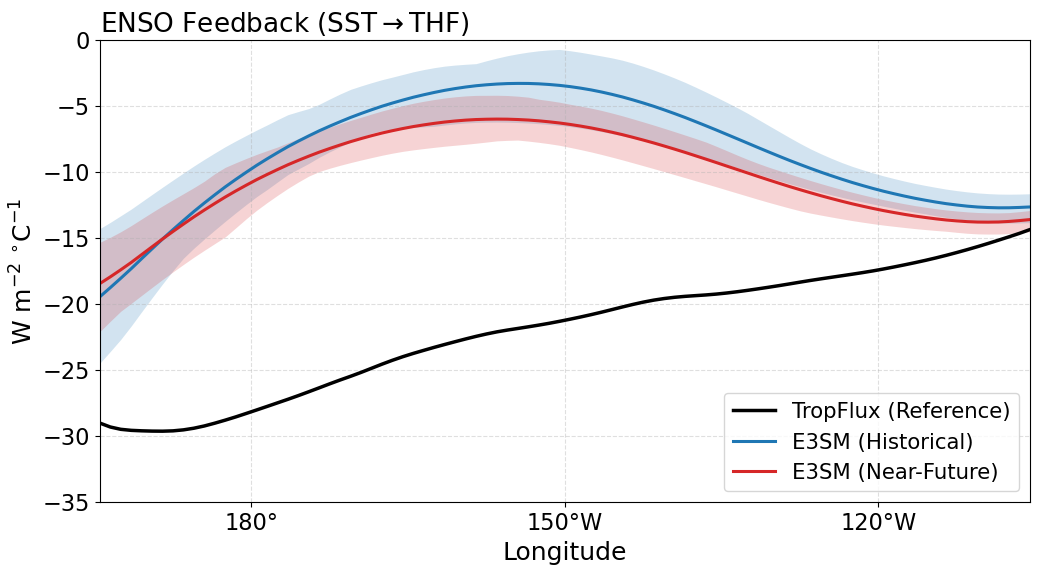

In [7]:
# Select one feedback metric and configure one or more comparison groups.
RUN_PLOTS = True
TARGET_METRIC = "enso_fb_sst_thf"
REFERENCE_SET = "TropFlux"  # "ERA-Interim-v0", "ERA-Interim", or "TropFlux"
SPREAD_MODE = "p05p95"  # "p05p95", "std", or "none"

DEFAULT_DATA_DIR = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le")
FIG_DIR = DEFAULT_DATA_DIR / "paper_plot"
READER_VERBOSE = False
DIAGNOSTIC_PRINT = True
POOL_MEMBERS_TO_SAMPLES = False

# A group source may be an EnsembleSource (patterned members) or one PCMDIRun.
# The default compares two 25-member ensembles without listing every member.
COMPARISON_GROUPS = [
    {
        "key": "historical",
        "label": "E3SM (Historical)",
        "source": EnsembleSource(
            data_dir=DEFAULT_DATA_DIR, model="v3.LR.historical",
            group="hist", period=(1985, 2014), nens=25,
        ),
        "color": "tab:blue",
    },
    {
        "key": "future",
        "label": "E3SM (Near-Future)",
        "source": EnsembleSource(
            data_dir=DEFAULT_DATA_DIR, model="v3.LR.historical",
            group="future", period=(2015, 2049), nens=25,
        ),
        "color": "tab:red",
    },
]

FEEDBACK_METRICS = {
    "enso_fb_sst_thf": {
        "variable": "reg_thf_over_sst_lon",
        "suffix": "EnsoFbSstThf",
        "label": r"ENSO Feedback (SST$\rightarrow$THF)",
        "unit": r"W m$^{-2}$ $^{\circ}$C$^{-1}$",
        "rtol": 1e-1,
    },
    "enso_fb_sst_taux": {
        "variable": "reg_taux_over_sst_lon",
        "suffix": "EnsoFbSstTaux",
        "label": r"ENSO Feedback (SST$\rightarrow$TAUX)",
        "unit": r"10$^{-3}$ N m$^{-2}$ $^{\circ}$C$^{-1}$",
        "rtol": 1e-1,
    },
    "enso_fb_ssh_sst": {
        "variable": "reg_sst_over_ssh_lon",
        "suffix": "EnsoFbSshSst",
        "label": r"ENSO Feedback (SSH$\rightarrow$SST)",
        "unit": r"$^{\circ}$C cm$^{-1}$",
        "rtol": 1e-2,
    },
    "enso_fb_taux_ssh": {
        "variable": "reg_ssh_over_taux_lon",
        "suffix": "EnsoFbTauxSsh",
        "label": r"ENSO Feedback (TAUX$\rightarrow$SSH)",
        "unit": r"10$^{-3}$ cm N$^{-1}$ m$^{2}$",
        "rtol": 1e-2,
    },
}

REFERENCE_SETS = {
    "ERA-Interim-v0": {
        "case_id": "v20251015",
        "observations": {
            "enso_fb_sst_thf": {"hist": "ERA-Interim_ERA-Interim", "future": "ERA-Interim2_ERA-Interim2"},
            "enso_fb_sst_taux": {"hist": "ERA-Interim_ERA-Interim", "future": "ERA-Interim2_ERA-Interim2"},
            "enso_fb_ssh_sst": {"hist": "ERA-Interim_AVISO", "future": "ERA-Interim2_AVISO2"},
            "enso_fb_taux_ssh": {"hist": "ERA-Interim_AVISO", "future": "ERA-Interim2_AVISO2"},
        },
        "ylims": {
            "enso_fb_sst_thf": (-24, 1),
            "enso_fb_sst_taux": (-4, 16),
            "enso_fb_ssh_sst": (-0.04, 0.28),
            "enso_fb_taux_ssh": (-0.08, 0.55),
        },
    },
    "ERA-Interim": {
        "case_id": "v20260216",
        "observations": {
            metric: {"hist": "ERA-Interim_ERA-Interim", "future": "FAKE-FUTURE1_FAKE-FUTURE1"}
            for metric in FEEDBACK_METRICS
        },
        "ylims": {
            "enso_fb_sst_thf": (-36, 36),
            "enso_fb_sst_taux": (-6, 16),
            "enso_fb_ssh_sst": (-0.1, 0.30),
            "enso_fb_taux_ssh": (-0.2, 0.60),
        },
    },
    "TropFlux": {
        "case_id": "v20260212",
        "observations": {
            "enso_fb_sst_thf": {"hist": "ERA-Interim_Tropflux", "future": "FAKE-FUTURE1_FAKE-FUTURE2"},
            "enso_fb_sst_taux": {"hist": "ERA-Interim_Tropflux", "future": "FAKE-FUTURE1_FAKE-FUTURE2"},
            "enso_fb_ssh_sst": {"hist": "ERA-Interim_Tropflux", "future": "FAKE-FUTURE1_FAKE-FUTURE2"},
            "enso_fb_taux_ssh": {"hist": "Tropflux_Tropflux", "future": "FAKE-FUTURE2_FAKE-FUTURE2"},
        },
        "ylims": {
            "enso_fb_sst_thf": (-35, 0),
            "enso_fb_sst_taux": (-4, 16),
            "enso_fb_ssh_sst": (-0.04, 0.28),
            "enso_fb_taux_ssh": (-0.08, 0.55),
        },
    },
}

REQUIRED_GROUP_FIELDS = {"key", "label", "source", "color"}
if not COMPARISON_GROUPS:
    raise ValueError("COMPARISON_GROUPS must contain at least one group")
for comparison in COMPARISON_GROUPS:
    missing = REQUIRED_GROUP_FIELDS - set(comparison)
    if missing:
        raise ValueError(f"Comparison group is missing fields: {sorted(missing)}")
    if not isinstance(comparison["source"], (EnsembleSource, PCMDIRun)):
        raise TypeError("source must be EnsembleSource or PCMDIRun")
group_keys = [comparison["key"] for comparison in COMPARISON_GROUPS]
if len(set(group_keys)) != len(group_keys):
    raise ValueError(f"Comparison keys must be unique, got {group_keys}")
if TARGET_METRIC not in FEEDBACK_METRICS:
    raise ValueError(f"TARGET_METRIC must be one of {list(FEEDBACK_METRICS)}")
if REFERENCE_SET not in REFERENCE_SETS:
    raise ValueError(f"REFERENCE_SET must be one of {list(REFERENCE_SETS)}")

metric_config = FEEDBACK_METRICS[TARGET_METRIC]
reference_config = REFERENCE_SETS[REFERENCE_SET]
ymin, ymax = reference_config["ylims"][TARGET_METRIC]
GROUP_STYLES = {
    "reference": {"label": f"{REFERENCE_SET} (Reference)", "color": "black", "alpha": 0.2},
    **{
        comparison["key"]: {"label": comparison["label"], "color": comparison["color"], "alpha": 0.2}
        for comparison in COMPARISON_GROUPS
    },
}

print(f"Metric: {TARGET_METRIC} ({metric_config['variable']})")
print(f"Reference set: {REFERENCE_SET}")
for comparison in COMPARISON_GROUPS:
    source = comparison["source"]
    if isinstance(source, EnsembleSource):
        obs_tag = reference_config["observations"][TARGET_METRIC][source.group]
        print(f"{comparison['key']}: ensemble model={source.model}, group={source.group}, nens={source.nens}, obs={obs_tag}")
    else:
        print(f"{comparison['key']}: PCMDIRun model={source.model_name}, case={source.metrics_case_id}")

if RUN_PLOTS:
    data_dict = {}
    run_references = []

    for comparison in COMPARISON_GROUPS:
        source = comparison["source"]
        if isinstance(source, EnsembleSource):
            obs_tag = reference_config["observations"][TARGET_METRIC][source.group]
            model_curve, run_reference, resolved_case_id = load_ensemble_source(
                source, TARGET_METRIC, metric_config, obs_tag, reference_config["case_id"]
            )
        else:
            # obs_tag is optional when the direct file has one unambiguous reference variable.
            model_curve, run_reference, resolved_case_id = load_pcmdi_run(
                source, metric_config, comparison.get("obs_tag")
            )
        run_references.append(run_reference)
        data_dict[comparison["key"]] = model_curve
        if DIAGNOSTIC_PRINT:
            da = data_dict[comparison["key"]]
            print(f"{comparison['key']}: case={resolved_case_id}, shape={da.shape}, dims={da.dims}")

    aligned_references = xr.align(*run_references, join="exact")
    for other_reference in aligned_references[1:]:
        if not np.allclose(aligned_references[0].values, other_reference.values, rtol=metric_config["rtol"], atol=0.0, equal_nan=True):
            raise ValueError("Comparison groups resolved different observational reference fields")
    data_dict["reference"] = aligned_references[0]

    plotter = ENSOFeedbackPlotter(
        data_dict=data_dict,
        fig_dir=FIG_DIR,
        plot_dict=GROUP_STYLES,
        group_order=group_keys,
    )
    comparison_tag = "_vs_".join(group_keys)
    output_name = f"enso_{TARGET_METRIC}_{comparison_tag}_{REFERENCE_SET.lower()}.pdf"
    plotter.plot(
        filename=output_name,
        title=metric_config["label"],
        ylabel=metric_config["unit"],
        ymin=ymin,
        ymax=ymax,
        spread_mode=SPREAD_MODE,
        lon_interval=30,
        figsize=(12, 6),
        font_size=18,
        dpi=300,
        figure_format="pdf",
    )
else:
    print("Set RUN_PLOTS = True after checking the resolved comparison groups above.")


Standalone metric: enso_fb_sst_thf (reg_thf_over_sst_lon)
Standalone groups: ['v3lr_0051', 'v3lr_0091', 'v3lr_0101', 'v3lr_0111']
Standalone figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_fb_sst_thf_v3lr_0051_vs_v3lr_0091_vs_v3lr_0101_vs_v3lr_0111_tropflux_standalone.pdf
v3lr_0051: case=v20260212, shape=(1, 90), dims=('member', 'longitude')
v3lr_0091: case=v20260212, shape=(1, 90), dims=('member', 'longitude')
v3lr_0101: case=v20260212, shape=(1, 90), dims=('member', 'longitude')
v3lr_0111: case=v20260212, shape=(1, 90), dims=('member', 'longitude')
Saved /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_fb_sst_thf_v3lr_0051_vs_v3lr_0091_vs_v3lr_0101_vs_v3lr_0111_tropflux_standalone.pdf


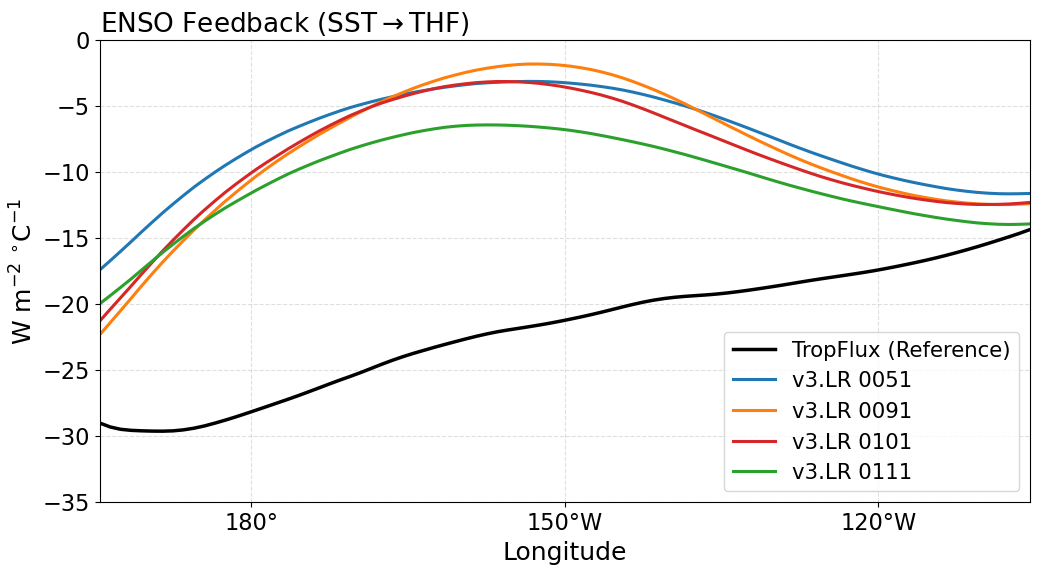

In [8]:
# Standalone PCMDI-run test (one member per plotted group).
# Run the cells above first so the loader, plotter, and metric definitions are available.
RUN_STANDALONE_PLOTS = True
STANDALONE_INPUT_DIR = DEFAULT_DATA_DIR / "hist"

#OUT_FIG_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/enso_feature_metrics")
#INPUT_DATA_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi")
# Example: four standalone PCMDI runs (one member per plotted group).
# COMPARISON_GROUPS = [
#     {"key": "v3_lr", 
#      "label": "v3.LR.CPL", 
#      "color": "tab:blue",
#      "source": PCMDIRun(case="20231209.v3.LR.piControl-spinup.chrysalis",
#                         model_name="EAMXX-ne256_coupled-test", 
#                         metrics_case_id="v20260531",
#                         output_name="v3.LR.CPL", 
#                         www=INPUT_DATA_DIR)
#     },
#     {"key": "v3_hr", 
#      "label": "v3.HR.CPL", 
#      "color": "tab:orange",
#      "source": PCMDIRun(case="20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis",
#                         model_name="v3-HR_test6-1", 
#                         metrics_case_id="v20260601",
#                         output_name="v3.HR.CPL", 
#                         www=INPUT_DATA_DIR)
#     },
#     {"key": "v4p", 
#      "label": "v4P.CPL",
#      "color": "tab:red",
#      "source": PCMDIRun(case="20260204.ne256.WCYCLXX1850.SOI",
#                         model_name="EAMXX-ne256_coupled-test", 
#                         metrics_case_id="v20260601",
#                         output_name="v4P.CPL", 
#                         www=INPUT_DATA_DIR)
#     },
#     {"key": "v4p_amip", 
#      "label": "v4P.AMIP",
#      "color": "tab:green",
#      "source": PCMDIRun(case="ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1",
#                         model_name="EAMXX_test2_1", 
#                         metrics_case_id="v20260531",
#                         output_name="v4P.AMIP", 
#                         www=INPUT_DATA_DIR)
#     },
# ]

# Four real v3.LR historical members, matching the test in plot_enso_feature_metric_v3le.ipynb.
COMPARISON_GROUPS = [
    {"key": "v3lr_0051", "label": "v3.LR 0051", "color": "tab:blue",
     "source": PCMDIRun(case="v3.LR.historical_0051", model_name="v3-LR_0051",
         metrics_case_id="v20260212", output_name="v3.LR 0051", www=STANDALONE_INPUT_DIR)},
    {"key": "v3lr_0091", "label": "v3.LR 0091", "color": "tab:orange",
     "source": PCMDIRun(case="v3.LR.historical_0091", model_name="v3-LR_0091",
         metrics_case_id="v20260212", output_name="v3.LR 0091", www=STANDALONE_INPUT_DIR)},
    {"key": "v3lr_0101", "label": "v3.LR 0101", "color": "tab:red",
     "source": PCMDIRun(case="v3.LR.historical_0101", model_name="v3-LR_0101",
         metrics_case_id="v20260212", output_name="v3.LR 0101", www=STANDALONE_INPUT_DIR)},
    {"key": "v3lr_0111", "label": "v3.LR 0111", "color": "tab:green",
     "source": PCMDIRun(case="v3.LR.historical_0111", model_name="v3-LR_0111",
         metrics_case_id="v20260212", output_name="v3.LR 0111", www=STANDALONE_INPUT_DIR)},
]

standalone_keys = [comparison["key"] for comparison in COMPARISON_GROUPS]
standalone_styles = {
    "reference": {"label": f"{REFERENCE_SET} (Reference)", "color": "black", "alpha": 0.2},
    **{comparison["key"]: {"label": comparison["label"],
                                  "color": comparison["color"], "alpha": 0.2}
       for comparison in COMPARISON_GROUPS},
}
standalone_tag = "_vs_".join(standalone_keys)
standalone_output_name = (
    f"enso_{TARGET_METRIC}_{standalone_tag}_{REFERENCE_SET.lower()}_standalone.pdf"
)

print(f"Standalone metric: {TARGET_METRIC} ({metric_config['variable']})")
print(f"Standalone groups: {standalone_keys}")
print(f"Standalone figure: {FIG_DIR / standalone_output_name}")

if RUN_STANDALONE_PLOTS:
    standalone_data = {}
    standalone_references = []
    for comparison in COMPARISON_GROUPS:
        source = comparison["source"]
        model_curve, run_reference, resolved_case_id = load_pcmdi_run(
            source, metric_config, comparison.get("obs_tag")
        )
        standalone_data[comparison["key"]] = model_curve
        standalone_references.append(run_reference)
        if DIAGNOSTIC_PRINT:
            print(
                f"{comparison['key']}: case={resolved_case_id}, "
                f"shape={model_curve.shape}, dims={model_curve.dims}"
            )

    aligned_references = xr.align(*standalone_references, join="exact")
    for other_reference in aligned_references[1:]:
        if not np.allclose(
            aligned_references[0].values, other_reference.values,
            rtol=metric_config["rtol"], atol=0.0, equal_nan=True,
        ):
            raise ValueError("Standalone runs resolved different observational reference fields")
    standalone_data["reference"] = aligned_references[0]

    standalone_plotter = ENSOFeedbackPlotter(
        data_dict=standalone_data, fig_dir=FIG_DIR, plot_dict=standalone_styles,
        group_order=standalone_keys,
    )
    standalone_plotter.plot(
        filename=standalone_output_name, title=metric_config["label"],
        ylabel=metric_config["unit"], ymin=ymin, ymax=ymax,
        spread_mode=SPREAD_MODE, lon_interval=30, figsize=(12, 6),
        font_size=18, dpi=300, figure_format="pdf",
    )
else:
    print("Set RUN_STANDALONE_PLOTS = True after reviewing the four runs above.")
